## Mathematical Definition of `newmark_components(f_2)`

The Newmark solver is written for the second-order form

$$
\mathbf{M}\,\ddot{\mathbf{u}} + \mathbf{C}\,\dot{\mathbf{u}} + \mathbf{f}_{\mathrm{int}}(\mathbf{u}) = \mathbf{f}_{\mathrm{ext}}(t),
\qquad
\mathbf{u} = \begin{bmatrix}u_1 \\ u_2\end{bmatrix}.
$$

For this internal-resonance model,

$$
\mathbf{M} = \mathbf{I}_2,
\qquad
\mathbf{C} =
\begin{bmatrix}
2\varepsilon\mu_1 & 0 \\
0 & 2\varepsilon\mu_2
\end{bmatrix}.
$$

The nonlinear internal force used in `f_int(u)` is

$$
\mathbf{f}_{\mathrm{int}}(\mathbf{u}) =
\begin{bmatrix}
\omega_1^2 u_1 - k_1 u_1 u_2 \\
\omega_2^2 u_2 - k_2 u_1^2
\end{bmatrix}.
$$

Its tangent Jacobian (used in Newton iterations) is

$$
\mathbf{K}_{\mathrm{tan}}(\mathbf{u})
= \frac{\partial \mathbf{f}_{\mathrm{int}}}{\partial \mathbf{u}}
=
\begin{bmatrix}
\omega_1^2 - k_1 u_2 & -k_1 u_1 \\
-2k_2 u_1 & \omega_2^2
\end{bmatrix}.
$$

The external forcing used in `f_ext(t)` is

$$
\mathbf{f}_{\mathrm{ext}}(t)=
\begin{bmatrix}
\varepsilon f_1\cos(\omega_2 t) \\
\varepsilon^2 f_2\cos(\omega_2 t)
\end{bmatrix}.
$$

So `newmark_components(f_2)` returns

$$
(\mathbf{M},\mathbf{C},\mathbf{f}_{\mathrm{int}},\mathbf{K}_{\mathrm{tan}},\mathbf{f}_{\mathrm{ext}})
$$

with the definitions above.

Newmark Integration: 100%|██████████| 40000/40000 [00:03<00:00, 10228.02step/s]


Benchmark summary
Mean runtime solve_ivp [s]: 1.8064
Mean runtime Newmark   [s]: 3.4733
Mean speedup (ivp/Newmark): 0.519x
Median a1 error [%]: 2.0401
Median a2 error [%]: 3.1968

        f2 |     a1_ivp |      a1_nm |     a2_ivp |      a2_nm |  err_a1[%] |  err_a2[%] |   relL2_u1 |   relL2_u2 |   t_ivp[s] |    t_nm[s] |     ivp/nm
    0.0000 | 3.0615e-07 | 3.1205e-07 | 9.5366e-10 | 8.5771e-10 |      1.924 |     10.060 |  1.346e-01 |  3.739e-01 |     0.5401 |     3.3252 |      0.162
   14.2857 | 1.2535e-06 | 1.2084e-06 | 5.4658e-06 | 5.3892e-06 |      3.599 |      1.401 |  1.420e-01 |  1.584e-01 |     1.6994 |     3.3774 |      0.503
   28.5714 | 5.0004e-06 | 4.7561e-06 | 1.0797e-05 | 1.0660e-05 |      4.885 |      1.263 |  1.405e-01 |  1.574e-01 |     1.9194 |     3.3222 |      0.578
   42.8571 | 1.8396e-05 | 1.7415e-05 | 1.4477e-05 | 1.4501e-05 |      5.335 |      0.166 |  1.292e-01 |  1.524e-01 |     2.0523 |     3.3151 |      0.619
   57.1429 | 4.3192e-05 | 4.2261e-05 | 1.0291e-05 

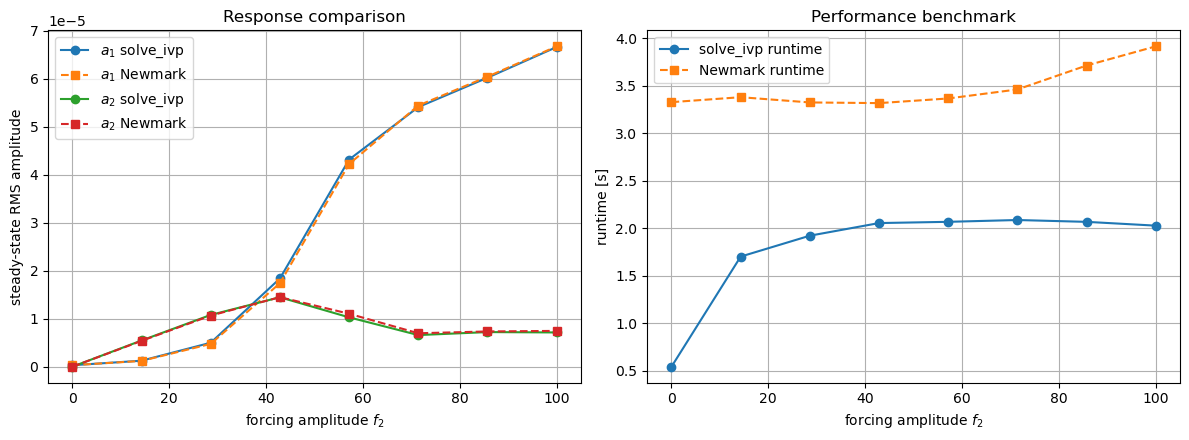

In [5]:
import sys
import time
from pathlib import Path

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Ensure we can import Modeling.models.newmark regardless of notebook working directory.
project_root = Path.cwd()
while project_root.name != "Metamaterial beam" and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Modeling.models.newmark import newmark_beta_nonlinear

# -----------------------------
# Internal resonance parameters
# -----------------------------
eps = 0.05
sigma1, sigma2 = 0.0, 0.0
freq_scale = 54 * 2 * pi
w1 = 1.0 * freq_scale
w2 = 2 * w1 - eps * sigma2
mu1, mu2 = 0.02 * freq_scale, 0.2 * freq_scale
k1, k2 = 400 * freq_scale**2, 400 * freq_scale**2
f1 = 0.0

# Force sweep (same scaling style used in internal_resonance_6.5.1)
f2_values = np.linspace(0, 0.25, 8) / eps**2

# Time settings
T_end = 20 / (mu2 * eps)
T_trans = 18 / (mu2 * eps)
dt_newmark = 1 / (10 * w2)  # 20 samples per period of highest frequency component

# Build one shared, exact time grid for both solvers.
n_steps = int(np.round(T_end / dt_newmark))
t_sim_end = n_steps * dt_newmark
t_eval = np.linspace(0.0, t_sim_end, n_steps + 1)

# Newmark parameters
beta = 0.25
gamma = 0.5


def forcing_vec(t, f2):
    return np.array([
        eps * f1 * np.cos(w2 * t),
        (eps**2) * f2 * np.cos(w2 * t),
    ])


def ivp_rhs(t, y, f2):
    u1, v1, u2, v2 = y
    F1 = eps * f1 * np.cos(w2 * t)
    F2 = (eps**2) * f2 * np.cos(w2 * t)

    du1 = v1
    dv1 = -w1**2 * u1 - 2 * eps * mu1 * v1 + k1 * u1 * u2 + F1
    du2 = v2
    dv2 = -w2**2 * u2 - 2 * eps * mu2 * v2 + k2 * u1**2 + F2
    return np.array([du1, dv1, du2, dv2])


def newmark_components(f2):
    M = np.eye(2)
    C = np.array([
        [2 * eps * mu1, 0.0],
        [0.0, 2 * eps * mu2],
    ])

    def f_int(u):
        u1, u2 = u
        return np.array([
            w1**2 * u1 - k1 * u1 * u2,
            w2**2 * u2 - k2 * u1**2,
        ])

    def K_tan(u):
        u1, u2 = u
        return np.array([
            [w1**2 - k1 * u2, -k1 * u1],
            [-2 * k2 * u1, w2**2],
        ])

    def f_ext(t):
        return forcing_vec(t, f2)

    return M, C, f_int, K_tan, f_ext


def rms_after_transient(t, s, t_trans):
    mask = t >= t_trans
    return np.sqrt(np.mean(s[mask] ** 2))


bench_rows = []

for f2 in f2_values:
    # -----------------
    # solve_ivp baseline
    # -----------------
    y0 = np.array([0.0, 1e-3, 0.0, 0.0])

    t0 = time.perf_counter()
    sol = solve_ivp(
        ivp_rhs,
        [0.0, t_sim_end],
        y0,
        args=(f2,),
        method="RK45",
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-8,
    )
    ivp_runtime = time.perf_counter() - t0

    u1_ivp = sol.y[0]
    u2_ivp = sol.y[2]
    a1_ivp = rms_after_transient(sol.t, u1_ivp, T_trans)
    a2_ivp = rms_after_transient(sol.t, u2_ivp, T_trans)

    # ----------------
    # Newmark solution
    # ----------------
    M, C, f_int, K_tan, f_ext = newmark_components(f2)
    u0 = np.array([0.0, 0.0])
    v0 = np.array([1e-3, 0.0])
    a0_init = np.linalg.solve(M, f_ext(0.0) - C @ v0 - f_int(u0))

    t0 = time.perf_counter()
    u_nm, v_nm, a_nm = newmark_beta_nonlinear(
        M=M,
        C=C,
        f_int=f_int,
        K_tan=K_tan,
        f_ext=f_ext,
        u0=u0,
        v0=v0,
        a0_init=a0_init,
        dt=dt_newmark,
        n_steps=n_steps,
        beta=beta,
        gamma=gamma,
        newton_tol=1e-7,
        newton_maxiter=25,
    )
    nm_runtime = time.perf_counter() - t0

    u1_nm = u_nm[:, 0]
    u2_nm = u_nm[:, 1]
    a1_nm = rms_after_transient(t_eval, u1_nm, T_trans)
    a2_nm = rms_after_transient(t_eval, u2_nm, T_trans)

    rel_l2_u1 = np.linalg.norm(u1_nm - u1_ivp) / (np.linalg.norm(u1_ivp) + 1e-16)
    rel_l2_u2 = np.linalg.norm(u2_nm - u2_ivp) / (np.linalg.norm(u2_ivp) + 1e-16)

    bench_rows.append({
        "f2": f2,
        "a1_ivp": a1_ivp,
        "a1_nm": a1_nm,
        "a2_ivp": a2_ivp,
        "a2_nm": a2_nm,
        "err_a1_pct": 100 * abs(a1_nm - a1_ivp) / (abs(a1_ivp) + 1e-16),
        "err_a2_pct": 100 * abs(a2_nm - a2_ivp) / (abs(a2_ivp) + 1e-16),
        "rel_l2_u1": rel_l2_u1,
        "rel_l2_u2": rel_l2_u2,
        "t_ivp_s": ivp_runtime,
        "t_nm_s": nm_runtime,
        "speedup_ivp_over_nm": ivp_runtime / (nm_runtime + 1e-16),
    })

f2_arr = np.array([r["f2"] for r in bench_rows])
a1_ivp_arr = np.array([r["a1_ivp"] for r in bench_rows])
a1_nm_arr = np.array([r["a1_nm"] for r in bench_rows])
a2_ivp_arr = np.array([r["a2_ivp"] for r in bench_rows])
a2_nm_arr = np.array([r["a2_nm"] for r in bench_rows])
t_ivp_arr = np.array([r["t_ivp_s"] for r in bench_rows])
t_nm_arr = np.array([r["t_nm_s"] for r in bench_rows])

print("Benchmark summary")
print(f"Mean runtime solve_ivp [s]: {np.mean(t_ivp_arr):.4f}")
print(f"Mean runtime Newmark   [s]: {np.mean(t_nm_arr):.4f}")
print(f"Mean speedup (ivp/Newmark): {np.mean(t_ivp_arr / t_nm_arr):.3f}x")
print(f"Median a1 error [%]: {np.median([r['err_a1_pct'] for r in bench_rows]):.4f}")
print(f"Median a2 error [%]: {np.median([r['err_a2_pct'] for r in bench_rows]):.4f}")

header = (
    "f2", "a1_ivp", "a1_nm", "a2_ivp", "a2_nm", "err_a1[%]", "err_a2[%]",
    "relL2_u1", "relL2_u2", "t_ivp[s]", "t_nm[s]", "ivp/nm"
)
print("\n" + " | ".join(f"{h:>10}" for h in header))
for r in bench_rows:
    print(" | ".join([
        f"{r['f2']:10.4f}",
        f"{r['a1_ivp']:10.4e}",
        f"{r['a1_nm']:10.4e}",
        f"{r['a2_ivp']:10.4e}",
        f"{r['a2_nm']:10.4e}",
        f"{r['err_a1_pct']:10.3f}",
        f"{r['err_a2_pct']:10.3f}",
        f"{r['rel_l2_u1']:10.3e}",
        f"{r['rel_l2_u2']:10.3e}",
        f"{r['t_ivp_s']:10.4f}",
        f"{r['t_nm_s']:10.4f}",
        f"{r['speedup_ivp_over_nm']:10.3f}",
    ]))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

axs[0].plot(f2_arr, a1_ivp_arr, "o-", label=r"$a_1$ solve_ivp")
axs[0].plot(f2_arr, a1_nm_arr, "s--", label=r"$a_1$ Newmark")
axs[0].plot(f2_arr, a2_ivp_arr, "o-", label=r"$a_2$ solve_ivp")
axs[0].plot(f2_arr, a2_nm_arr, "s--", label=r"$a_2$ Newmark")
axs[0].set_xlabel(r"forcing amplitude $f_2$")
axs[0].set_ylabel("steady-state RMS amplitude")
axs[0].set_title("Response comparison")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(f2_arr, t_ivp_arr, "o-", label="solve_ivp runtime")
axs[1].plot(f2_arr, t_nm_arr, "s--", label="Newmark runtime")
axs[1].set_xlabel(r"forcing amplitude $f_2$")
axs[1].set_ylabel("runtime [s]")
axs[1].set_title("Performance benchmark")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()